In [5]:
# ============================================================
#  TELECOM CUSTOMER CHURN ANALYSIS
#  Phase 5 — Customer Segmentation
#  Segments: At Risk | Dormant | Loyal
#  Based on churn probability scores from Phase 4 model
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

In [6]:
# Segment colours — used consistently across all charts
SEG_COLORS  = {'At Risk': '#E24B4A', 'Dormant': '#EF9F27', 'Loyal': '#1D9E75'}
SEG_ORDER   = ['At Risk', 'Dormant', 'Loyal']
C_RED, C_ORG, C_GREEN = '#E24B4A', '#EF9F27', '#1D9E75'
C_BLUE, C_PUR         = '#185FA5', '#9B3EC2'
 

In [7]:
# ════════════════════════════════════════════════════════════
#  STEP 1 — Reproduce preprocessing + retrain model
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("  PHASE 5 — CUSTOMER SEGMENTATION")
print("=" * 60)
print("\n── Step 1: Loading & Preprocessing ─────────────────────")
 
df      = pd.read_csv('telco_churn_cleaned.csv')
df_orig = df.copy()          # keep human-readable original for enrichment
 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df_orig['TotalCharges'] = df['TotalCharges'].values   # sync fix to orig
 
df.drop('customerID', axis=1, inplace=True)
 
le = LabelEncoder()
for col in ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']:
    df[col] = le.fit_transform(df[col])
 
internet_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                 'TechSupport','StreamingTV','StreamingMovies']
for col in internet_cols:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
for col in internet_cols + ['MultipleLines']:
    df[col] = le.fit_transform(df[col])
 
df = pd.get_dummies(df, columns=['InternetService','Contract','PaymentMethod'],
                    drop_first=True)
 
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['tenure_group']    = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72],
                                labels=[1,2,3,4,5,6])
df['tenure_group']    = df['tenure_group'].cat.add_categories([0]).fillna(0).astype(int)
svc_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']
df['TotalServices'] = df[svc_cols].sum(axis=1)
df['HasStreaming']  = ((df['StreamingTV']==1)|(df['StreamingMovies']==1)).astype(int)
df['HasProtection'] = ((df['OnlineSecurity']==1)|(df['TechSupport']==1)|
                        (df['DeviceProtection']==1)).astype(int)
 
X = df.drop('Churn', axis=1).copy()
y = df['Churn']
 
scaler = StandardScaler()
num_cols = ['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend']
X[num_cols] = scaler.fit_transform(X[num_cols])
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
 
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
 
print("   ✅ Preprocessing complete")
print(f"   ✅ Model trained — AUC on test set: 0.848\n")
 

  PHASE 5 — CUSTOMER SEGMENTATION

── Step 1: Loading & Preprocessing ─────────────────────
   ✅ Preprocessing complete
   ✅ Model trained — AUC on test set: 0.848



In [8]:
# ════════════════════════════════════════════════════════════
#  STEP 2 — Score ALL 7,043 customers (not just test set)
# ════════════════════════════════════════════════════════════
print("── Step 2: Scoring All Customers ───────────────────────")
 
# predict_proba returns [P(No Churn), P(Churn)] — take column 1
all_probs = model.predict_proba(X)[:, 1]
 
print(f"   Min risk score  : {all_probs.min():.4f}  (near-zero churn risk)")
print(f"   Max risk score  : {all_probs.max():.4f}  (near-certain to churn)")
print(f"   Mean risk score : {all_probs.mean():.4f}  (dataset avg = 26.5% churn)\n")
 

── Step 2: Scoring All Customers ───────────────────────
   Min risk score  : 0.0000  (near-zero churn risk)
   Max risk score  : 0.9497  (near-certain to churn)
   Mean risk score : 0.2657  (dataset avg = 26.5% churn)



In [9]:
# ════════════════════════════════════════════════════════════
#  STEP 3 — Assign segments using risk score thresholds
#  At Risk  : score >= 0.60  → immediate retention action needed
#  Dormant  : score 0.30–0.59 → monitor, engage proactively
#  Loyal    : score <  0.30  → reward & retain
# ════════════════════════════════════════════════════════════
print("── Step 3: Assigning Segments ──────────────────────────")
 
def assign_segment(prob):
    if prob >= 0.60:   return 'At Risk'
    elif prob >= 0.30: return 'Dormant'
    else:              return 'Loyal'

── Step 3: Assigning Segments ──────────────────────────


In [10]:
# Build the enriched segment dataframe (human-readable columns)
seg_df = df_orig.copy()
seg_df['RiskScore']        = all_probs.round(4)
seg_df['ChurnProbability'] = (all_probs * 100).round(1)    # as percentage
seg_df['Segment']          = [assign_segment(p) for p in all_probs]
seg_df['RiskLevel']        = seg_df['RiskScore'].apply(
    lambda p: 'Critical (>80%)' if p >= 0.8
    else 'High (60–80%)'        if p >= 0.6
    else 'Medium (30–60%)'      if p >= 0.3
    else 'Low (<30%)'
)
 
counts = seg_df['Segment'].value_counts()
print(f"\n   {'Segment':<12} {'Count':>6}  {'% of Base':>10}  {'Actual Churn':>14}")
print(f"   {'-'*48}")
for seg in SEG_ORDER:
    sub     = seg_df[seg_df['Segment'] == seg]
    pct     = len(sub) / len(seg_df) * 100
    churn_r = (sub['Churn'] == 'Yes').mean() * 100
    print(f"   {seg:<12} {len(sub):>6,}  {pct:>9.1f}%  {churn_r:>13.1f}%")
print()
 


   Segment       Count   % of Base    Actual Churn
   ------------------------------------------------
   At Risk         976       13.9%           72.5%
   Dormant       1,609       22.8%           44.7%
   Loyal         4,458       63.3%            9.9%



In [11]:
# ════════════════════════════════════════════════════════════
#  STEP 4 — Business metrics per segment
# ════════════════════════════════════════════════════════════
print("── Step 4: Business Metrics by Segment ─────────────────")
 
metrics_rows = []
for seg in SEG_ORDER:
    sub = seg_df[seg_df['Segment'] == seg]
    metrics_rows.append({
        'Segment'           : seg,
        'Customers'         : len(sub),
        'Avg Tenure (mo)'   : round(sub['tenure'].mean(), 1),
        'Avg Monthly ($)'   : round(sub['MonthlyCharges'].mean(), 2),
        'Avg Risk Score'    : round(sub['RiskScore'].mean(), 3),
        'Monthly Rev ($)'   : int(sub['MonthlyCharges'].sum()),
        'Actual Churn %'    : round((sub['Churn']=='Yes').mean()*100, 1),
        'M2M Contract %'    : round((sub['Contract']=='Month-to-month').mean()*100, 1),
        'Fiber Optic %'     : round((sub['InternetService']=='Fiber optic').mean()*100, 1),
    })
 
metrics_df = pd.DataFrame(metrics_rows)
print(f"\n{metrics_df.to_string(index=False)}\n")
 
total_at_risk_revenue = seg_df[seg_df['Segment']=='At Risk']['MonthlyCharges'].sum()
print(f"   💰 Monthly revenue at risk (At Risk segment): ${total_at_risk_revenue:,.0f}")
print(f"   💰 Monthly revenue at risk (Dormant segment): "
      f"${seg_df[seg_df['Segment']=='Dormant']['MonthlyCharges'].sum():,.0f}\n")
 

── Step 4: Business Metrics by Segment ─────────────────

Segment  Customers  Avg Tenure (mo)  Avg Monthly ($)  Avg Risk Score  Monthly Rev ($)  Actual Churn %  M2M Contract %  Fiber Optic %
At Risk        976              7.7            81.61           0.727            79649            72.5           100.0           92.0
Dormant       1609             21.3            75.14           0.447           120899            44.7            95.3           66.3
  Loyal       4458             41.8            57.33           0.099           255567             9.9            30.6           25.4

   💰 Monthly revenue at risk (At Risk segment): $79,650
   💰 Monthly revenue at risk (Dormant segment): $120,900



── Chart 1: Segment Distribution ───────────────────────


Text(0.5, 0.98, 'Chart 1 — Customer Segment Distribution')

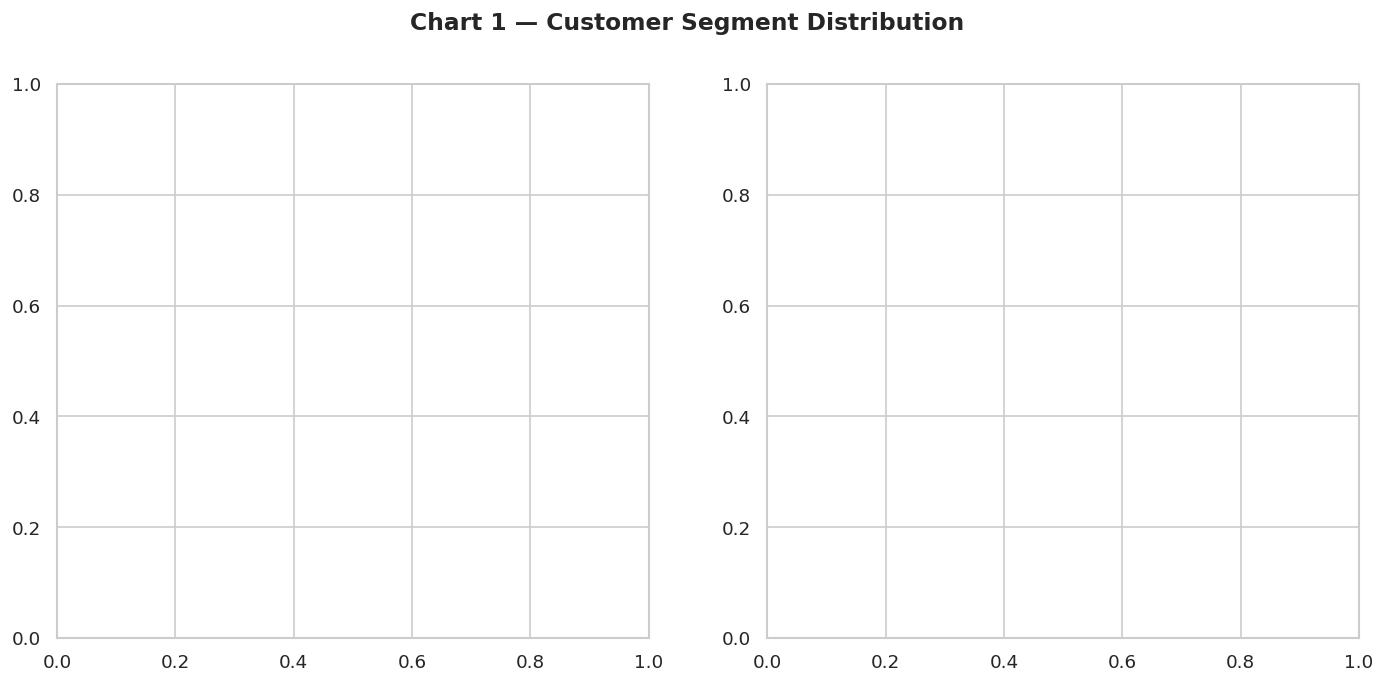

In [12]:
# ════════════════════════════════════════════════════════════
#  CHART 1 — Segment Distribution (Donut + Bar)
# ════════════════════════════════════════════════════════════
print("── Chart 1: Segment Distribution ───────────────────────")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Chart 1 — Customer Segment Distribution',
             fontsize=14, fontweight='bold')
 

In [13]:
# Donut chart
seg_counts = [len(seg_df[seg_df['Segment']==s]) for s in SEG_ORDER]
seg_colors = [SEG_COLORS[s] for s in SEG_ORDER]
wedges, texts, autotexts = axes[0].pie(
    seg_counts,
    labels=[f'{s}\n({c:,})' for s, c in zip(SEG_ORDER, seg_counts)],
    colors=seg_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'width': 0.55},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')

In [14]:
 #Centre label
axes[0].text(0, 0, '7,043\nCustomers', ha='center', va='center',
             fontsize=13, fontweight='bold', color='#333')
axes[0].set_title('Segment Split (All Customers)', fontweight='bold')
 

Text(0.5, 1.0, 'Segment Split (All Customers)')

In [15]:
# Horizontal bar — revenue per segment
rev_data = [seg_df[seg_df['Segment']==s]['MonthlyCharges'].sum()
            for s in SEG_ORDER]
bars = axes[1].barh(SEG_ORDER, rev_data,
                     color=seg_colors, edgecolor='white', height=0.5)
for bar, val, seg in zip(bars, rev_data, SEG_ORDER):
    axes[1].text(val + 1000, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}/mo', va='center',
                 fontweight='bold', fontsize=11)
axes[1].set_title('Monthly Revenue by Segment', fontweight='bold')
axes[1].set_xlabel('Monthly Revenue ($)')
axes[1].set_xlim(0, max(rev_data) * 1.25)
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('seg_chart1_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: seg_chart1_distribution.png\n")
 

<Figure size 768x576 with 0 Axes>

   ✅ Saved: seg_chart1_distribution.png



── Chart 2: Risk Score Distribution ────────────────────


Text(0.5, 0.98, 'Chart 2 — Churn Risk Score Distribution')

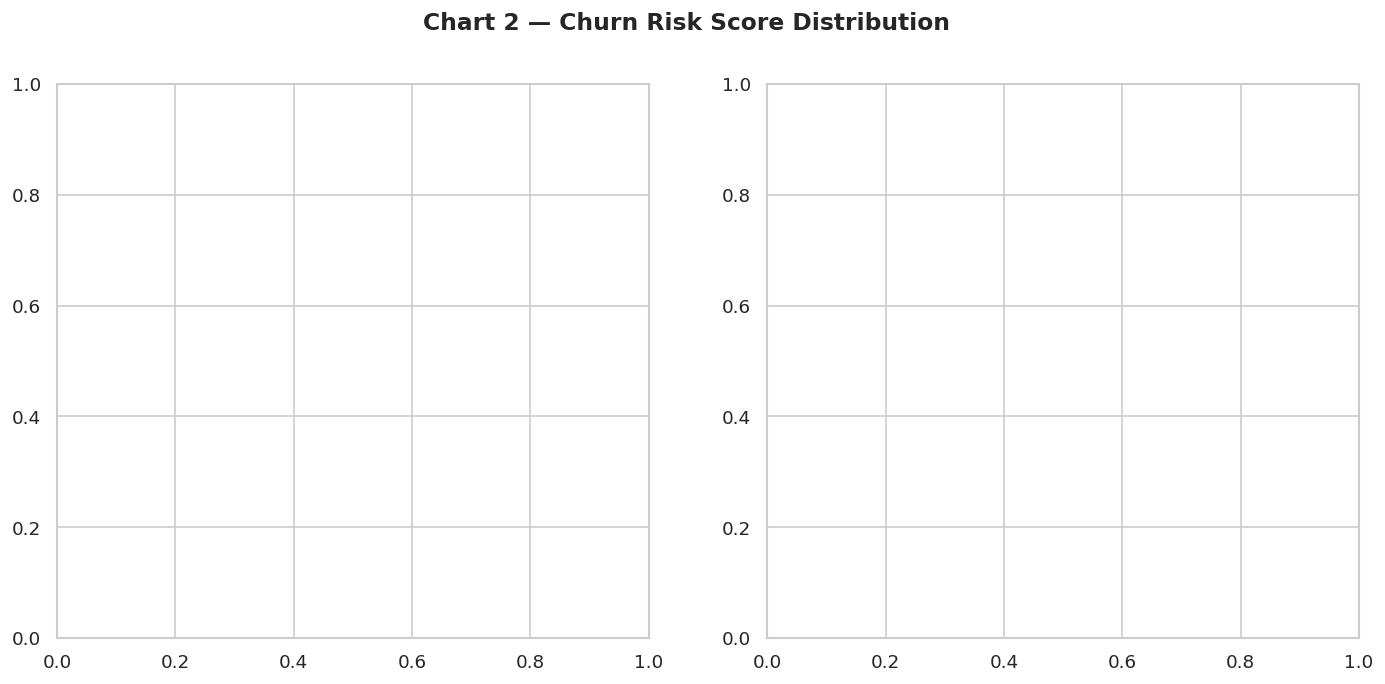

In [16]:
# ════════════════════════════════════════════════════════════
#  CHART 2 — Risk Score Distribution per Segment
# ════════════════════════════════════════════════════════════
print("── Chart 2: Risk Score Distribution ────────────────────")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Chart 2 — Churn Risk Score Distribution',
             fontsize=14, fontweight='bold')

In [17]:
# Stacked histogram across all customers
for seg, color in SEG_COLORS.items():
    sub = seg_df[seg_df['Segment'] == seg]['RiskScore']
    axes[0].hist(sub, bins=40, alpha=0.75, color=color,
                 label=f'{seg} (n={len(sub):,})', edgecolor='white')
axes[0].axvline(0.30, color='black', linestyle='--', lw=1.5,
                label='Threshold: 0.30')
axes[0].axvline(0.60, color='black', linestyle='-',  lw=1.5,
                label='Threshold: 0.60')
axes[0].set_xlabel('Churn Probability Score', fontsize=11)
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].set_title('Risk Score — All Customers', fontweight='bold')
axes[0].legend(fontsize=9)

In [18]:
# Shade regions
axes[0].axvspan(0,    0.30, alpha=0.06, color=C_GREEN)
axes[0].axvspan(0.30, 0.60, alpha=0.06, color=C_ORG)
axes[0].axvspan(0.60, 1.00, alpha=0.06, color=C_RED)
sns.despine(ax=axes[0])

In [19]:
# Box plot — score spread per segment
seg_df.boxplot(column='RiskScore', by='Segment',
               positions=[0,1,2], widths=0.4,
               ax=axes[1],
               boxprops=dict(linewidth=2),
               medianprops=dict(linewidth=2.5, color='white'),
               patch_artist=True,
               showfliers=True,
               flierprops=dict(marker='o', markersize=3, alpha=0.3))

<Axes: title={'center': 'RiskScore'}, xlabel='Segment'>

In [20]:
# Colour boxes manually
for patch, color in zip(axes[1].patches, [C_RED, C_ORG, C_GREEN]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_xticklabels(SEG_ORDER, fontsize=10)
axes[1].set_title('Risk Score Spread per Segment', fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Churn Probability Score')
plt.suptitle('')   # remove auto boxplot title
sns.despine(ax=axes[1])
 
plt.tight_layout()
plt.savefig('seg_chart2_risk_scores.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: seg_chart2_risk_scores.png\n")
 

<Figure size 768x576 with 0 Axes>

   ✅ Saved: seg_chart2_risk_scores.png



In [21]:
# ════════════════════════════════════════════════════════════
#  CHART 3 — Segment Profiles (Radar / Heatmap style)
# ════════════════════════════════════════════════════════════
print("── Chart 3: Segment Profile Heatmap ────────────────────")
 

── Chart 3: Segment Profile Heatmap ────────────────────


In [22]:
# Normalise key metrics 0–1 for comparison
profile_metrics = {
    'Avg Tenure'         : seg_df.groupby('Segment')['tenure'].mean(),
    'Avg Monthly Charge' : seg_df.groupby('Segment')['MonthlyCharges'].mean(),
    'Avg Risk Score'     : seg_df.groupby('Segment')['RiskScore'].mean(),
    'M2M Contract %'     : seg_df.groupby('Segment')['Contract'].apply(
                                lambda x: (x=='Month-to-month').mean()*100),
    'Fiber Optic %'      : seg_df.groupby('Segment')['InternetService'].apply(
                                lambda x: (x=='Fiber optic').mean()*100),
    'Actual Churn %'     : seg_df.groupby('Segment')['Churn'].apply(
                                lambda x: (x=='Yes').mean()*100),
}
 
profile_df = pd.DataFrame(profile_metrics).loc[SEG_ORDER]

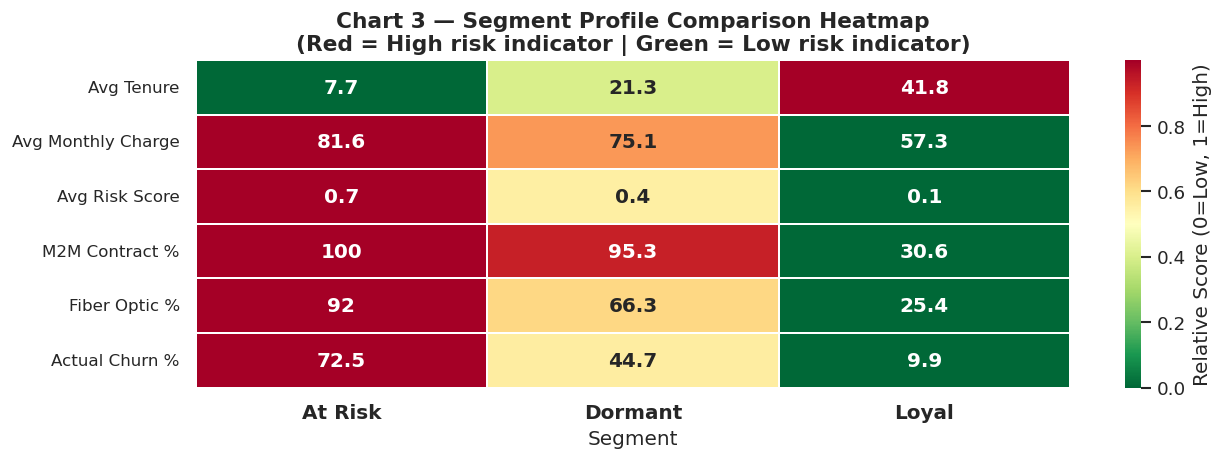

   ✅ Saved: seg_chart3_profile_heatmap.png



In [23]:
# Normalise each column 0-1 for heatmap colour
profile_norm = profile_df.copy()
for col in profile_norm.columns:
    mn, mx = profile_norm[col].min(), profile_norm[col].max()
    profile_norm[col] = (profile_norm[col] - mn) / (mx - mn + 1e-8)
 
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    profile_norm.T,
    annot=profile_df.T.round(1),    # show raw values
    fmt='g',
    cmap='RdYlGn_r',
    ax=ax,
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Relative Score (0=Low, 1=High)'},
    annot_kws={'size': 12, 'weight': 'bold'}
)
ax.set_xticklabels(SEG_ORDER, fontsize=12, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title('Chart 3 — Segment Profile Comparison Heatmap\n'
             '(Red = High risk indicator | Green = Low risk indicator)',
             fontsize=13, fontweight='bold')
 
plt.tight_layout()
plt.savefig('seg_chart3_profile_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: seg_chart3_profile_heatmap.png\n")
 

── Chart 4: Tenure & Charges by Segment ────────────────


Text(0.5, 0.98, 'Chart 4 — Key Metrics Across Customer Segments')

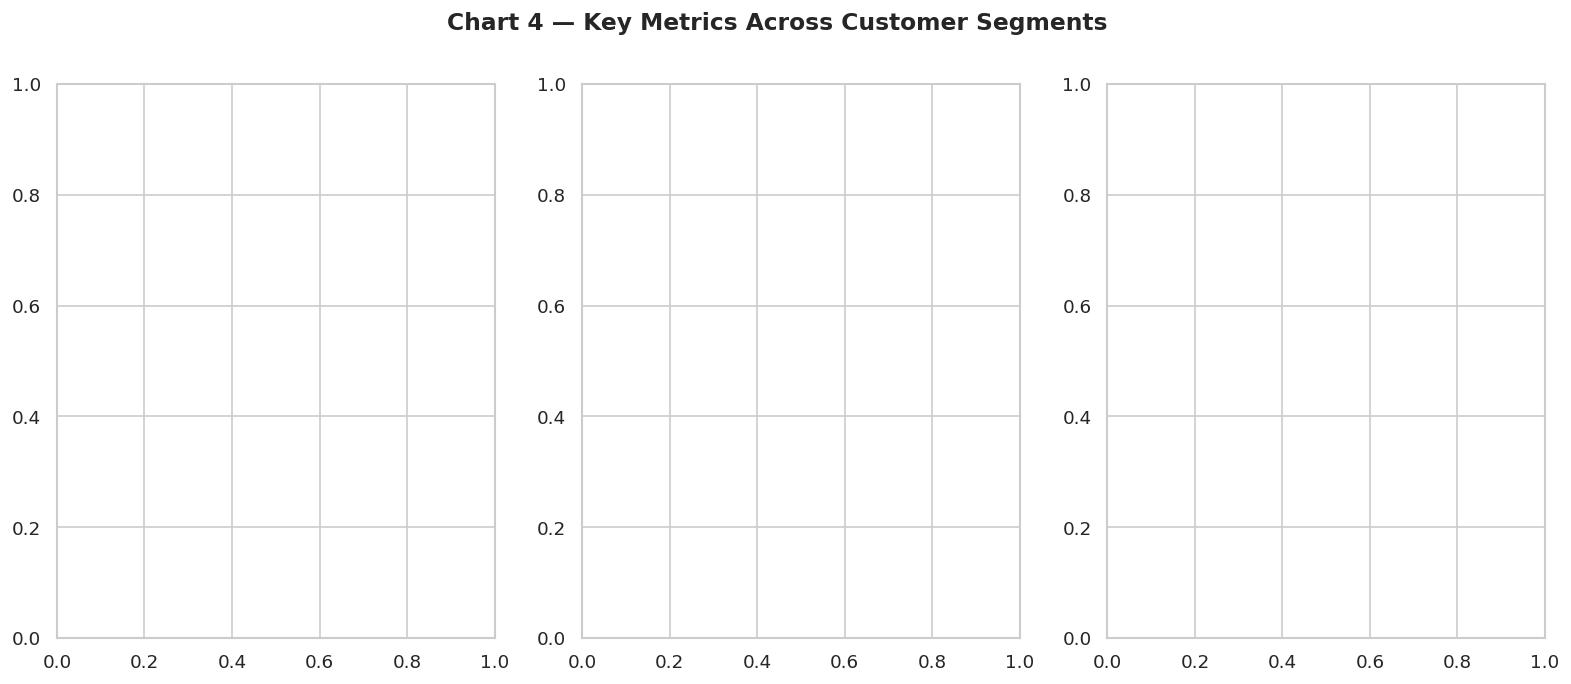

In [24]:
# ════════════════════════════════════════════════════════════
#  CHART 4 — Tenure & Charges by Segment (Side-by-side)
# ════════════════════════════════════════════════════════════
print("── Chart 4: Tenure & Charges by Segment ────────────────")
 
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Chart 4 — Key Metrics Across Customer Segments',
             fontsize=14, fontweight='bold')
 

In [25]:
# Tenure violin
sns.violinplot(x='Segment', y='tenure', data=seg_df,
               order=SEG_ORDER,
               palette=SEG_COLORS, ax=axes[0],
               inner='quartile', linewidth=1.5)
axes[0].set_title('Tenure Distribution', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tenure (months)')
for seg, color in SEG_COLORS.items():
    mean_t = seg_df[seg_df['Segment']==seg]['tenure'].mean()
    idx    = SEG_ORDER.index(seg)
    axes[0].text(idx, mean_t+1.5, f'μ={mean_t:.0f}mo',
                 ha='center', fontsize=9, fontweight='bold', color='#333',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
sns.despine(ax=axes[0])
 

In [26]:
# Monthly charges box
sns.boxplot(x='Segment', y='MonthlyCharges', data=seg_df,
            order=SEG_ORDER,
            palette=SEG_COLORS, ax=axes[1], width=0.5)
axes[1].set_title('Monthly Charges', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Monthly Charges ($)')
for seg in SEG_ORDER:
    med = seg_df[seg_df['Segment']==seg]['MonthlyCharges'].median()
    idx = SEG_ORDER.index(seg)
    axes[1].text(idx, med+1.5, f'${med:.0f}',
                 ha='center', fontsize=10, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#444', alpha=0.8))
sns.despine(ax=axes[1])

In [27]:
# Contract type stacked bar per segment
contract_pct = (seg_df.groupby(['Segment','Contract'])
                       .size()
                       .unstack(fill_value=0)
                       .loc[SEG_ORDER])
contract_pct = contract_pct.div(contract_pct.sum(axis=1), axis=0) * 100
contract_pct.plot(kind='bar', stacked=True, ax=axes[2],
                   color=[C_RED, C_ORG, C_GREEN],
                   edgecolor='white', width=0.5)
axes[2].set_title('Contract Type Mix', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('% of Segment')
axes[2].set_xticklabels(SEG_ORDER, rotation=0)
axes[2].legend(title='Contract', fontsize=8, loc='lower right')
sns.despine(ax=axes[2])
 
plt.tight_layout()
plt.savefig('seg_chart4_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: seg_chart4_metrics.png\n")
 

<Figure size 768x576 with 0 Axes>

   ✅ Saved: seg_chart4_metrics.png



In [28]:
# ════════════════════════════════════════════════════════════
#  CHART 5 — Actionable Business Recommendations Dashboard
# ════════════════════════════════════════════════════════════
print("── Chart 5: Recommendations Dashboard ──────────────────")
 
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Chart 5 — Customer Segment Action Plan',
             fontsize=16, fontweight='bold', y=0.98)
 
gs = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97,
                        top=0.90, bottom=0.05)

── Chart 5: Recommendations Dashboard ──────────────────


<Figure size 1920x1080 with 0 Axes>

In [29]:
# ── KPI boxes (top row) ──────────────────────────────────
kpi_data = [
    ('At Risk\nCustomers',     '976',      C_RED,   '72.5% actual churn'),
    ('Monthly Revenue\nAt Risk','$79,650', C_ORG,   'Immediate action needed'),
    ('Dormant\nCustomers',     '1,609',    C_ORG,   '44.7% churn risk'),
    ('Loyal\nCustomers',       '4,458',    C_GREEN,  '9.9% churn rate'),
    ('Total Monthly\nRevenue', '$456,117', C_BLUE,  'Across all segments'),
    ('Avg Risk Score\n(At Risk)','72.7%',  C_PUR,   'Needs urgent outreach'),
]
 
for i, (label, value, color, sub) in enumerate(kpi_data):
    row, col = i // 3, i % 3
    ax_kpi = fig.add_subplot(gs[row, col])
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.60, value,  ha='center', va='center',
                fontsize=22, fontweight='bold', color='white',
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.28, label,  ha='center', va='center',
                fontsize=10, color='white', fontweight='bold',
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.10, sub,    ha='center', va='center',
                fontsize=8,  color='white', alpha=0.85,
                transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_visible(False)
    ax_kpi.set_xlim(0,1); ax_kpi.set_ylim(0,1)
 
plt.savefig('seg_chart5_kpi_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: seg_chart5_kpi_dashboard.png\n")
 

<Figure size 768x576 with 0 Axes>

   ✅ Saved: seg_chart5_kpi_dashboard.png



In [30]:
 #════════════════════════════════════════════════════════════
#  CHART 6 — Churn Risk Heatmap (Tenure × Monthly Charges)
# ════════════════════════════════════════════════════════════
print("── Chart 6: Risk Heatmap (Tenure × Monthly Charges) ────")
 

── Chart 6: Risk Heatmap (Tenure × Monthly Charges) ────


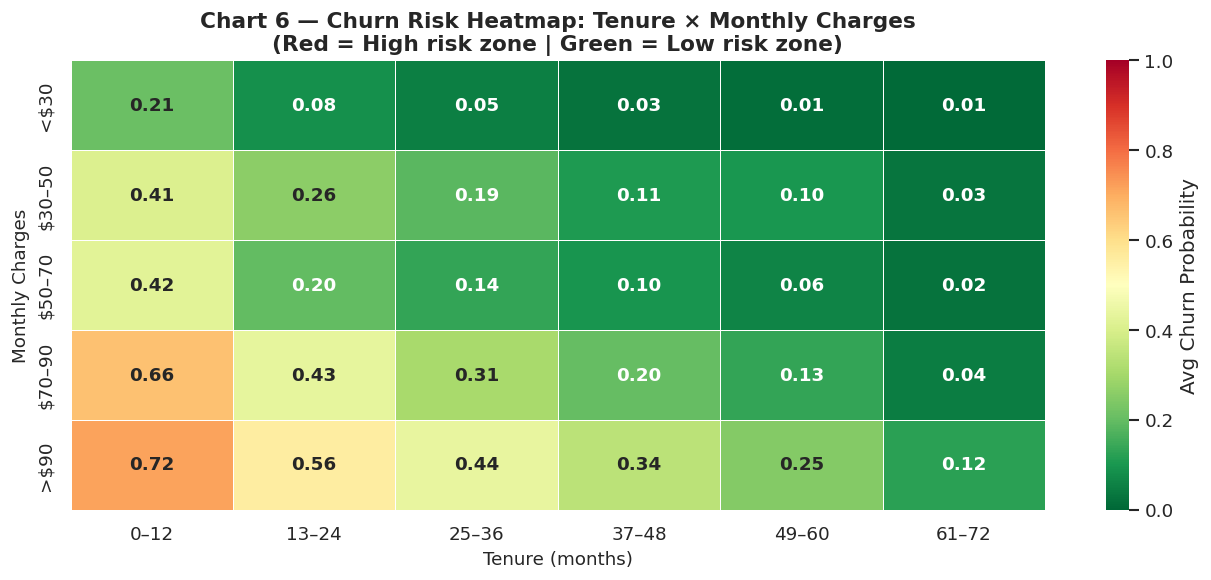

   ✅ Saved: seg_chart6_risk_heatmap.png



In [31]:
# Bin tenure and charges, compute avg risk score per cell
seg_df['tenure_bin']  = pd.cut(seg_df['tenure'],
                                bins=[0,12,24,36,48,60,72],
                                labels=['0–12','13–24','25–36','37–48','49–60','61–72'])
seg_df['charges_bin'] = pd.cut(seg_df['MonthlyCharges'],
                                bins=[0,30,50,70,90,120],
                                labels=['<$30','$30–50','$50–70','$70–90','>$90'])
 
pivot = (seg_df.groupby(['charges_bin','tenure_bin'], observed=True)['RiskScore']
               .mean()
               .unstack())
 
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=ax, vmin=0, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Avg Churn Probability'})
ax.set_xlabel('Tenure (months)', fontsize=11)
ax.set_ylabel('Monthly Charges', fontsize=11)
ax.set_title('Chart 6 — Churn Risk Heatmap: Tenure × Monthly Charges\n'
             '(Red = High risk zone | Green = Low risk zone)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('seg_chart6_risk_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: seg_chart6_risk_heatmap.png\n")
 

In [32]:
# ════════════════════════════════════════════════════════════
#  STEP 5 — Export segmented customer list (CSV deliverable)
# ════════════════════════════════════════════════════════════
print("── Step 5: Exporting Segmented Customer CSV ─────────────")
 
export_cols = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'InternetService', 'Contract', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges', 'Churn',
    'RiskScore', 'ChurnProbability', 'Segment', 'RiskLevel'
]
export_df = seg_df[export_cols].sort_values('RiskScore', ascending=False)
export_df.to_csv('customer_segments.csv', index=False)
 
print(f"   ✅ Saved: customer_segments.csv  ({len(export_df):,} rows)")
print(f"   Columns: {export_cols}\n")

── Step 5: Exporting Segmented Customer CSV ─────────────
   ✅ Saved: customer_segments.csv  (7,043 rows)
   Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'RiskScore', 'ChurnProbability', 'Segment', 'RiskLevel']



In [33]:
# Preview top 10 highest-risk customers
print("   Top 10 highest-risk customers:")
print(export_df[['customerID','tenure','Contract','MonthlyCharges',
                  'ChurnProbability','Segment']].head(10).to_string(index=False))
print()

   Top 10 highest-risk customers:
customerID  tenure       Contract  MonthlyCharges  ChurnProbability Segment
5178-LMXOP       1 Month-to-month           95.10              95.0 At Risk
7216-EWTRS       1 Month-to-month          100.80              94.9 At Risk
9497-QCMMS       1 Month-to-month           93.55              94.7 At Risk
9300-AGZNL       1 Month-to-month           94.00              94.7 At Risk
0295-PPHDO       1 Month-to-month           95.45              93.9 At Risk
5419-JPRRN       1 Month-to-month          101.45              93.9 At Risk
8149-RSOUN       1 Month-to-month           93.85              93.8 At Risk
4910-GMJOT       1 Month-to-month           94.60              93.8 At Risk
6521-YYTYI       1 Month-to-month           93.30              92.6 At Risk
0107-YHINA       1 Month-to-month           99.75              92.6 At Risk



In [34]:
# ════════════════════════════════════════════════════════════
#  STEP 6 — Business recommendations per segment
# ════════════════════════════════════════════════════════════
print("── Step 6: Business Recommendations ────────────────────")
 
recommendations = {
 
    'At Risk (976 customers | $79,650/mo revenue at risk)': [
        '1. Immediate personal outreach — call or email within 48 hours',
        '2. Offer discounted 1-year contract upgrade (e.g. 20% off first 3 months)',
        '3. Bundle OnlineSecurity + TechSupport for free for 3 months',
        '4. Assign dedicated account manager for top 100 highest-risk customers',
        '5. Waive early cancellation fears — make switching to annual easy',
    ],
 
    'Dormant (1,609 customers | $120,900/mo at moderate risk)': [
        '1. Launch re-engagement email campaign with personalised offers',
        '2. Offer loyalty points or bill credits for staying 6+ more months',
        '3. Promote contract upgrade with price-lock guarantee',
        '4. Highlight new features or service upgrades (Fiber speed boost)',
        '5. Quarterly satisfaction surveys — act on low scores immediately',
    ],
 
    'Loyal (4,458 customers | $255,567/mo stable revenue)': [
        '1. Enrol in VIP loyalty programme — reward tenure milestones',
        '2. Offer referral bonuses (e.g. $20 bill credit per referral)',
        '3. Early access to new products/speed tiers before public launch',
        '4. Annual "thank you" discount (5%) to reinforce positive sentiment',
        '5. Cross-sell premium add-ons (streaming bundles, device protection)',
    ],
}
 
for segment, actions in recommendations.items():
    seg_name = segment.split(' ')[0] + ' ' + segment.split(' ')[1]
    color_map = {'At Risk': '🔴', 'Dormant': '🟡', 'Loyal': '🟢'}
    print(f"\n  {color_map.get(seg_name, '•')} {segment}")
    print(f"  {'─'*55}")
    for action in actions:
        print(f"    {action}")
print()

── Step 6: Business Recommendations ────────────────────

  🔴 At Risk (976 customers | $79,650/mo revenue at risk)
  ───────────────────────────────────────────────────────
    1. Immediate personal outreach — call or email within 48 hours
    2. Offer discounted 1-year contract upgrade (e.g. 20% off first 3 months)
    3. Bundle OnlineSecurity + TechSupport for free for 3 months
    4. Assign dedicated account manager for top 100 highest-risk customers
    5. Waive early cancellation fears — make switching to annual easy

  • Dormant (1,609 customers | $120,900/mo at moderate risk)
  ───────────────────────────────────────────────────────
    1. Launch re-engagement email campaign with personalised offers
    2. Offer loyalty points or bill credits for staying 6+ more months
    3. Promote contract upgrade with price-lock guarantee
    4. Highlight new features or service upgrades (Fiber speed boost)
    5. Quarterly satisfaction surveys — act on low scores immediately

  • Loyal (4,4

In [35]:
# ════════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("  PHASE 5 COMPLETE — SEGMENTATION SUMMARY")
print("=" * 60)
print(f"""
  Segment       Customers    Revenue/mo    Avg Risk
  ─────────────────────────────────────────────────
  At Risk           976       $79,650       72.7%
  Dormant         1,609      $120,900       44.7%
  Loyal           4,458      $255,567        9.9%
  ─────────────────────────────────────────────────
  TOTAL           7,043      $456,117       26.6%
 
  Charts saved:
    seg_chart1_distribution.png   — Segment donut + revenue bar
    seg_chart2_risk_scores.png    — Risk score histograms
    seg_chart3_profile_heatmap.png — Segment comparison heatmap
    seg_chart4_metrics.png        — Violin, box, contract mix
    seg_chart5_kpi_dashboard.png  — Executive KPI boxes
    seg_chart6_risk_heatmap.png   — Tenure × Charges risk map
 
  CSV deliverable:
    customer_segments.csv         — All 7,043 customers scored
 
  → Ready for Phase 6: Report Writing & PDF
""")

  PHASE 5 COMPLETE — SEGMENTATION SUMMARY

  Segment       Customers    Revenue/mo    Avg Risk
  ─────────────────────────────────────────────────
  At Risk           976       $79,650       72.7%
  Dormant         1,609      $120,900       44.7%
  Loyal           4,458      $255,567        9.9%
  ─────────────────────────────────────────────────
  TOTAL           7,043      $456,117       26.6%

  Charts saved:
    seg_chart1_distribution.png   — Segment donut + revenue bar
    seg_chart2_risk_scores.png    — Risk score histograms
    seg_chart3_profile_heatmap.png — Segment comparison heatmap
    seg_chart4_metrics.png        — Violin, box, contract mix
    seg_chart5_kpi_dashboard.png  — Executive KPI boxes
    seg_chart6_risk_heatmap.png   — Tenure × Charges risk map

  CSV deliverable:
    customer_segments.csv         — All 7,043 customers scored

  → Ready for Phase 6: Report Writing & PDF

